In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def plot_accuracy_comparison_bars(
    method_1_accuracies,
    method_2_accuracies,
    method_1_stds=None,
    method_2_stds=None,
    params=[100, 200, 300, 400],
    width=35,           # bar width in same units as params
    figsize=(10, 6)
):
    if len(method_1_accuracies) != len(params) or len(method_2_accuracies) != len(params):
        raise ValueError("Both accuracy lists must have the same length as params.")

    if method_1_stds is not None and len(method_1_stds) != len(params):
        raise ValueError("method_1_stds must have the same length as params.")
    if method_2_stds is not None and len(method_2_stds) != len(params):
        raise ValueError("method_2_stds must have the same length as params.")

    x = np.array(params)
    width = (max(x) - min(x)) * 0.08 if len(x) > 1 else 20  # auto-scale width reasonably

    fig, ax = plt.subplots(figsize=figsize)

    method_1_vals = np.array(method_1_accuracies, dtype=float)
    method_2_vals = np.array(method_2_accuracies, dtype=float)
    method_1_err = np.array(method_1_stds, dtype=float) if method_1_stds is not None else None
    method_2_err = np.array(method_2_stds, dtype=float) if method_2_stds is not None else None

    error_style = {'elinewidth': 1.2, 'capsize': 4, 'capthick': 1.2}

    bars_pca = ax.bar(
        x - width/2,
        method_1_vals,
        width,
        yerr=method_1_err,
        label='PCA-rank',
        color='lightblue',
        edgecolor='blue',
        linewidth=1.2,
        error_kw=error_style
    )
    bars_rnd = ax.bar(
        x + width/2,
        method_2_vals,
        width,
        yerr=method_2_err,
        label='Random Sampling',
        color='lightgreen',
        edgecolor='green',
        linewidth=1.2,
        error_kw=error_style
    )
    ax.tick_params(axis='both', labelsize=12)

    # Vertical labels inside each bar, near the top, in mean ± std format.
    x_text_offset = width * 0.05

    for i, bar in enumerate(bars_pca):
        h = bar.get_height()
        std_val = method_1_err[i] if method_1_err is not None else 0.0
        label = f"{h:.3f} ± {std_val:.3f}"
        y_pos = max(h - 0.06, h * 0.65)
        ax.text(
            bar.get_x() + bar.get_width() / 2 + x_text_offset,
            y_pos,
            label,
            ha='center',
            va='top',
            rotation=90,
            fontsize=12,
            color='black'
        )

    for i, bar in enumerate(bars_rnd):
        h = bar.get_height()
        std_val = method_2_err[i] if method_2_err is not None else 0.0
        label = f"{h:.3f} ± {std_val:.3f}"
        y_pos = max(h - 0.06, h * 0.65)
        ax.text(
            bar.get_x() + bar.get_width() / 2 + x_text_offset,
            y_pos,
            label,
            ha='center',
            va='top',
            rotation=90,
            fontsize=12,
            color='black'
        )

    ax.set_xlabel('Selected Taxels', fontsize=14)
    ax.set_ylabel('Validation Accuracy', fontsize=14)
    ax.set_ylim(0, 1.05)
    ax.set_xticks(x)
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)
    ax.legend(loc='best', fontsize=14)

    plt.tight_layout()
    plt.savefig('figures/topn_random_comparison.png', dpi=400, bbox_inches='tight', facecolor='white')
    plt.show()

In [4]:
def plot_topk_baseline_vs_ours_bars(
    baseline_top1,
    baseline_top3,
    our_top1,
    our_top3,
    params,
    baseline_top1_stds=None,
    baseline_top3_stds=None,
    our_top1_stds=None,
    our_top3_stds=None,
    figsize=(10, 4.8),
    save_path=None,
    y_label='Accuracy [%]',
    x_label='Session',
 ):
    """Plot 4 bars per parameter with a publication-style visual theme.

    Per parameter, the bars are placed as:
    baseline Top-1 | baseline Top-3    (gap)    our Top-1 | our Top-3
    """
    # Accept a single scalar (int/float/str) or any iterable of labels/values.
    if isinstance(params, (str, int, float, np.integer, np.floating)):
        params = [params]
    else:
        params = list(params)

    n = len(params)
    for arr, name in [
        (baseline_top1, 'baseline_top1'),
        (baseline_top3, 'baseline_top3'),
        (our_top1, 'our_top1'),
        (our_top3, 'our_top3'),
    ]:
        if len(arr) != n:
            raise ValueError(f"{name} must have the same length as params.")

    for arr, name in [
        (baseline_top1_stds, 'baseline_top1_stds'),
        (baseline_top3_stds, 'baseline_top3_stds'),
        (our_top1_stds, 'our_top1_stds'),
        (our_top3_stds, 'our_top3_stds'),
    ]:
        if arr is not None and len(arr) != n:
            raise ValueError(f"{name} must have the same length as params.")

    b1 = np.array(baseline_top1, dtype=float)
    b3 = np.array(baseline_top3, dtype=float)
    o1 = np.array(our_top1, dtype=float)
    o3 = np.array(our_top3, dtype=float)

    b1_err = np.array(baseline_top1_stds, dtype=float) if baseline_top1_stds is not None else None
    b3_err = np.array(baseline_top3_stds, dtype=float) if baseline_top3_stds is not None else None
    o1_err = np.array(our_top1_stds, dtype=float) if our_top1_stds is not None else None
    o3_err = np.array(our_top3_stds, dtype=float) if our_top3_stds is not None else None

    x = np.arange(n, dtype=float)
    bar_w = 0.18
    pair_gap = 0.03
    block_gap = 0.12

    # Offsets: two adjacent baseline bars, a gap, then two adjacent our bars.
    off_b1 = -(1.5 * bar_w + pair_gap / 2 + block_gap / 2)
    off_b3 = off_b1 + bar_w + pair_gap
    off_o1 = off_b3 + bar_w + block_gap
    off_o3 = off_o1 + bar_w + pair_gap

    # Serif typography + subtle paper-like styling.
    style = {
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'STIXGeneral', 'DejaVu Serif'],
        'axes.labelsize': 16,
        'axes.titlesize': 16,
        'xtick.labelsize': 15,
        'ytick.labelsize': 13,
    }
    with plt.rc_context(style):
        fig, ax = plt.subplots(figsize=figsize)
        
        error_style = {'elinewidth': 1.0, 'capsize': 3, 'capthick': 1.0}

        # Lighter neutral palettes: warm clay for baseline, soft slate-blue for our study.
        bars_b1 = ax.bar(
            x + off_b1, b1, bar_w, yerr=b1_err,
            label='CNN Top-1', color='#b08968', edgecolor='#7a5a44', linewidth=0.9, error_kw=error_style
        )
        bars_b3 = ax.bar(
            x + off_b3, b3, bar_w, yerr=b3_err,
            label='CNN Top-3', color='#ddc5b2', edgecolor='#7a5a44', linewidth=0.9, error_kw=error_style
        )
        bars_o1 = ax.bar(
            x + off_o1, o1, bar_w, yerr=o1_err,
            label='SNN Top-1', color='#6f8fa3', edgecolor='#4f6b7d', linewidth=0.9, error_kw=error_style
        )
        bars_o3 = ax.bar(
            x + off_o3, o3, bar_w, yerr=o3_err,
            label='SNN Top-3', color='#c8d7e1', edgecolor='#4f6b7d', linewidth=0.9, error_kw=error_style
        )
        x_text_offset = bar_w * 0.05
        # Vertical values inside bars, matching the attached style.
        for bar_group in [bars_b1, bars_b3, bars_o1, bars_o3]:
            for bar in bar_group:
                h = bar.get_height()
                if np.isnan(h):
                    continue
                y_pos = max(h - 2.0, h * 0.60)
                ax.text(
                    bar.get_x() + bar.get_width() / 2 + x_text_offset,
                    y_pos,
                    f"{h:.2f}",
                    ha='center',
                    va='top',
                    rotation=90,
                    fontsize=12,
                    color='black'
                )

        # Remove x-axis label per request.
        ax.set_xlabel('')
        ax.set_ylabel(y_label)
        ax.set_xticks(x)
        ax.set_xticklabels([str(p) for p in params], fontsize=15)

        ymax = np.nanmax(np.concatenate([b1, b3, o1, o3])) if n > 0 else 1.0
        upper = 100 if ymax <= 100 else ymax * 1.08
        ax.set_ylim(0, upper)
        if upper == 100:
            ax.set_yticks(np.arange(0, 101, 20))

        ax.grid(True, axis='y', linestyle='-', linewidth=0.8, color='#9ca3af', alpha=0.65)
        ax.set_axisbelow(True)

        # Longer x ticks + labels farther from axis; hide y tick marks.
        ax.tick_params(axis='x', labelsize=15, width=0.9, length=8, pad=10)
        ax.tick_params(axis='y', labelsize=13, width=0.8, length=0, pad=6)

        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
            spine.set_color('#374151')

        ax.legend(
            loc='upper left',
            fontsize=11,
            frameon=True,
            facecolor='white',
            edgecolor='#d1d5db',
            framealpha=1.0
        )
        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=400, bbox_inches='tight', facecolor=fig.get_facecolor())
        plt.show()

In [5]:
def plot_cnn_vs_snn_topk_bars(
    cnn_top1,
    cnn_top3,
    snn_top1,
    snn_top3,
    cnn_top1_std=None,
    cnn_top3_std=None,
    snn_top1_std=None,
    snn_top3_std=None,
    figsize=(7, 5),
    y_label='Accuracy [%]',
    save_path=None,
    legend_position='upper left',
 ):
    """Compare CNN vs SNN on Top-1 and Top-3 with two bars per metric."""

    cnn_vals = np.array([cnn_top1, cnn_top3], dtype=float)
    snn_vals = np.array([snn_top1, snn_top3], dtype=float)

    cnn_err = None
    snn_err = None
    if any(v is not None for v in [cnn_top1_std, cnn_top3_std]):
        if cnn_top1_std is None or cnn_top3_std is None:
            raise ValueError('Provide both cnn_top1_std and cnn_top3_std, or neither.')
        cnn_err = np.array([cnn_top1_std, cnn_top3_std], dtype=float)
    if any(v is not None for v in [snn_top1_std, snn_top3_std]):
        if snn_top1_std is None or snn_top3_std is None:
            raise ValueError('Provide both snn_top1_std and snn_top3_std, or neither.')
        snn_err = np.array([snn_top1_std, snn_top3_std], dtype=float)

    x = np.arange(2, dtype=float)
    labels = ['Top-1', 'Top-3']
    bar_w = 0.24
    pair_gap = 0.08
    x_offset = bar_w / 2 + pair_gap / 2

    style = {
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'STIXGeneral', 'DejaVu Serif'],
        'axes.labelsize': 16,
        'axes.titlesize': 16,
        'xtick.labelsize': 15,
        'ytick.labelsize': 13,
    }

    with plt.rc_context(style):
        fig, ax = plt.subplots(figsize=figsize)
        fig.patch.set_facecolor('white')
        ax.set_facecolor('white')

        error_style = {'elinewidth': 1.0, 'capsize': 3, 'capthick': 1.0}

        bars_cnn = ax.bar(
            x - x_offset, cnn_vals, bar_w, yerr=cnn_err,
            label='CNN', color='#b8a188', edgecolor='#7a5a44', linewidth=0.9, error_kw=error_style
        )
        bars_snn = ax.bar(
            x + x_offset, snn_vals, bar_w, yerr=snn_err,
            label='SNN', color='#9fb6c6', edgecolor='#4f6b7d', linewidth=0.9, error_kw=error_style
        )

        for bars, errs in [(bars_cnn, cnn_err), (bars_snn, snn_err)]:
            for i, bar in enumerate(bars):
                h = bar.get_height()
                if np.isnan(h):
                    continue
                std_val = errs[i] if errs is not None else 0.0

                # Always use two-line labels and keep them farther from the error-bar segment.
                label_text = f'{h:.2f}\n± {std_val:.2f}'
                y_drop = 4.0 + 1 * std_val
                y_pos = max(h - y_drop, h * 0.35, 2.5)
                text_rotation = 90
                text_size = 16
                text_va = 'top'

                x_text_offset = bar_w * 0.02

                ax.text(
                    bar.get_x() + bar.get_width() / 2 + x_text_offset,
                    y_pos,
                    label_text,
                    ha='center',
                    va=text_va,
                    rotation=text_rotation,
                    fontsize=text_size,
                    color='black'
                )

        ax.set_xlabel('')
        ax.set_ylabel(y_label)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, fontsize=15)

        ymax = np.nanmax(np.concatenate([cnn_vals, snn_vals]))
        upper = 100 if ymax <= 100 else ymax * 1.08
        ax.set_ylim(0, upper)
        if upper == 100:
            ax.set_yticks(np.arange(0, 101, 20))

        ax.grid(True, axis='y', linestyle='-', linewidth=0.8, color='#9ca3af', alpha=0.65)
        ax.set_axisbelow(True)
        ax.tick_params(axis='x', labelsize=15, width=0.9, length=8, pad=10)
        ax.tick_params(axis='y', labelsize=13, width=0.8, length=0, pad=6)

        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
            spine.set_color('#374151')

        ax.legend(
            loc=legend_position,
            fontsize=11,
            frameon=True,
            facecolor='white',
            edgecolor='#d1d5db',
            framealpha=1.0
        )

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=400, bbox_inches='tight', facecolor=fig.get_facecolor())
        plt.show()

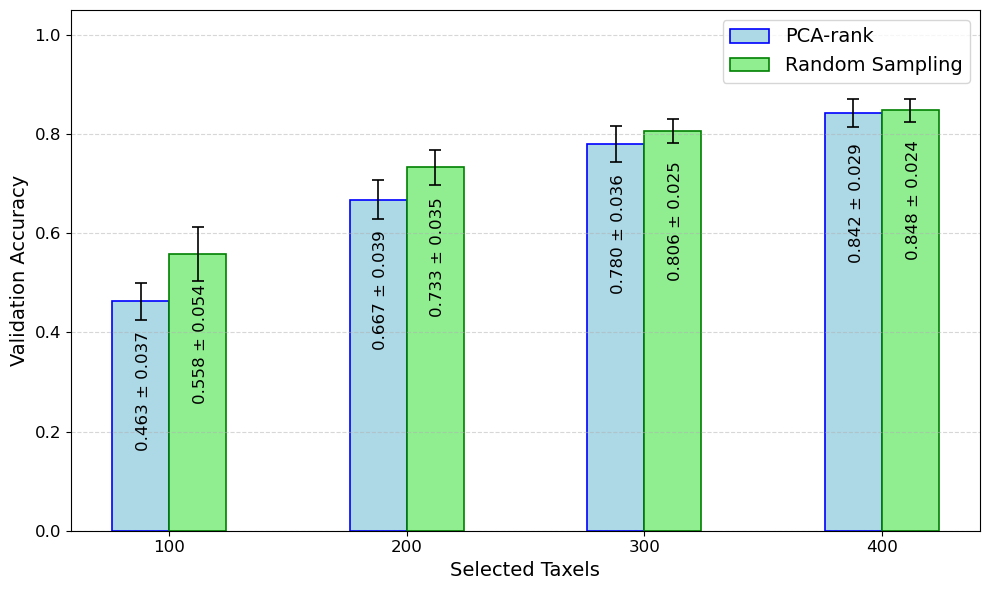

In [6]:
plot_accuracy_comparison_bars(
    method_1_accuracies = [0.463, 0.667, 0.780, 0.842], #pca-rank
    method_2_accuracies = [0.558, 0.733, 0.806, 0.848], #random
    method_1_stds       = [0.0375, 0.0392, 0.0358, 0.0285], 
    method_2_stds       = [0.0542, 0.0351, 0.0251, 0.0235]
)

## Wang et al comparison - all dataset - Dense

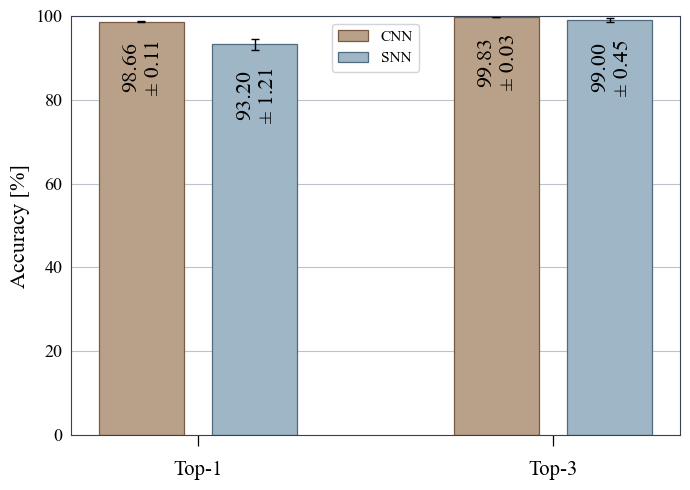

In [7]:
plot_cnn_vs_snn_topk_bars(
    cnn_top1=98.66,
    cnn_top3=99.83,
    snn_top1=93.20,
    snn_top3=99.00,
    cnn_top1_std=0.11,
    cnn_top3_std=0.03,
    snn_top1_std=1.21,
    snn_top3_std=0.45,
    save_path='figures/cnn_snn_1a.png',
    legend_position='upper center'
)

## Wang et al comparison - all dataset - fan in 64

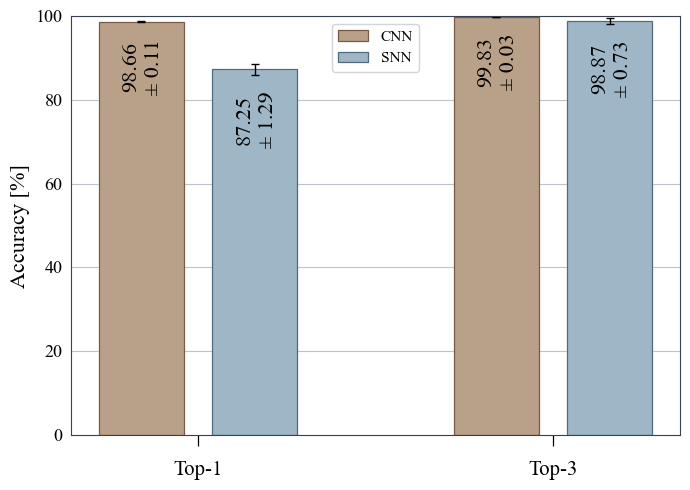

In [8]:
plot_cnn_vs_snn_topk_bars(
    cnn_top1=98.66,
    cnn_top3=99.83,
    snn_top1=87.25,
    snn_top3=98.87,
    cnn_top1_std=0.11,
    cnn_top3_std=0.03,
    snn_top1_std=1.29,
    snn_top3_std=0.73,
    save_path='figures/cnn_vs_snn_topk_fanin.png',
    legend_position='upper center'
)

## Wang et al comparison - intersession average - fan-in

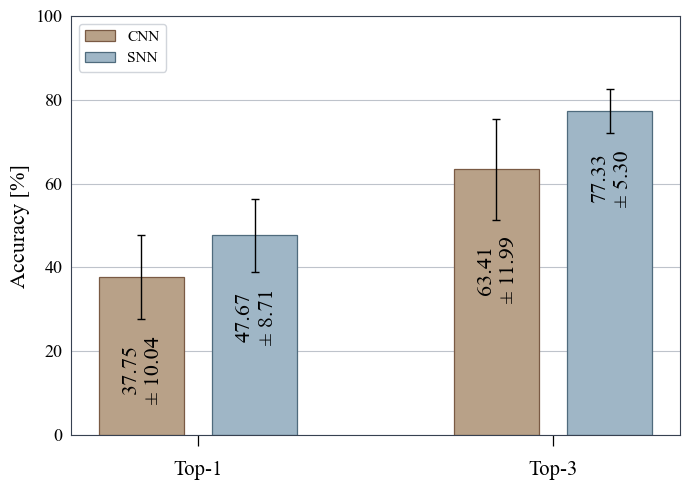

In [7]:
plot_cnn_vs_snn_topk_bars(
    cnn_top1=37.75,
    cnn_top3=63.41,
    snn_top1=47.67,
    snn_top3=77.33,
    cnn_top1_std=10.04,
    cnn_top3_std=11.99,
    snn_top1_std=8.71,
    snn_top3_std=5.30,
    save_path='figures/cnn_snn_2.png',
)

## Wang et al comparison - intersession average - dense

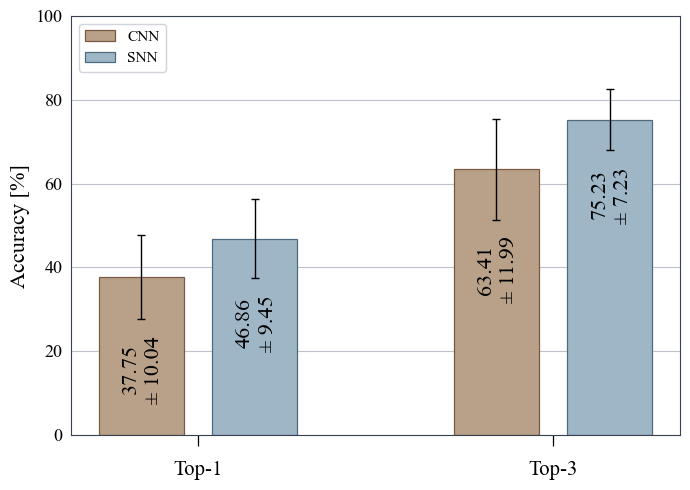

In [8]:
plot_cnn_vs_snn_topk_bars(
    cnn_top1=37.75,
    cnn_top3=63.41,
    snn_top1=46.86,
    snn_top3=75.23,
    cnn_top1_std=10.04,
    cnn_top3_std=11.99,
    snn_top1_std=9.45,
    snn_top3_std=7.23,
    save_path='figures/cnn_snn_1b.png',
)

## Wang et al comparison - inter session - Dense

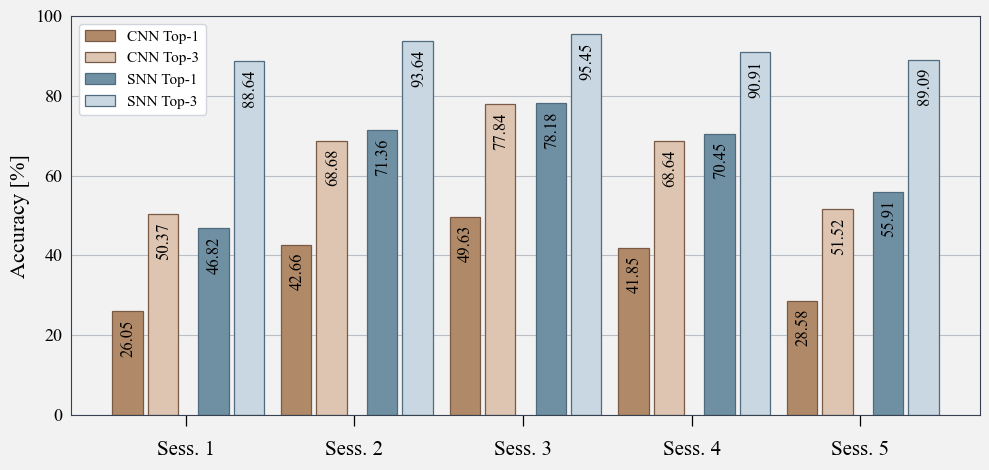

In [115]:
plot_topk_baseline_vs_ours_bars(
    baseline_top1=[26.05, 42.66, 49.63, 41.85, 28.58],
    baseline_top3=[50.37, 68.68, 77.84, 68.64, 51.52],
    our_top1=[46.82, 71.36, 78.18, 70.45, 55.91],
    our_top3=[88.64, 93.64, 95.45, 90.91, 89.09],
    params=['Sess. 1', 'Sess. 2', 'Sess. 3', 'Sess. 4', 'Sess. 5'],
    y_label='Accuracy [%]',
    x_label='Session',
    save_path='figures/cnn_vs_snn_intersession_dense.png'
 )

## Wang et al comparison - inter session - fanin 64

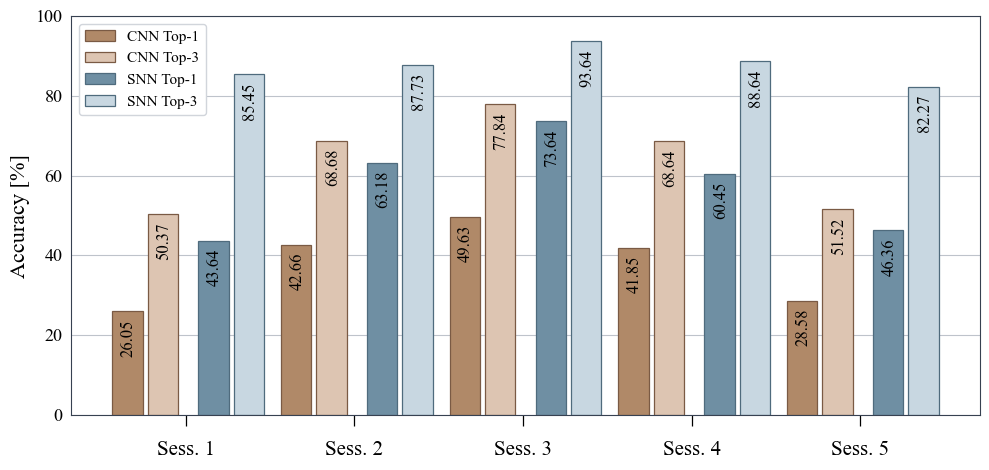

In [19]:
plot_topk_baseline_vs_ours_bars(
    baseline_top1=[26.05, 42.66, 49.63, 41.85, 28.58],
    baseline_top3=[50.37, 68.68, 77.84, 68.64, 51.52],
    our_top1=[43.64, 63.18, 73.64, 60.45, 46.36],
    our_top3=[85.45, 87.73, 93.64, 88.64, 82.27],
    params=['Sess. 1', 'Sess. 2', 'Sess. 3', 'Sess. 4', 'Sess. 5'],
    y_label='Accuracy [%]',
    x_label='Session',
    save_path='figures/cnn_snn_3.png'
 )